In [14]:
import pandas as pd
import numpy as np

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("Libraries imported successfully.")

Libraries imported successfully.


In [15]:
train = pd.read_csv("../data/processed/train_features.csv")
validation = pd.read_csv("../data/processed/validation_features.csv")
test = pd.read_csv("../data/processed/test_features.csv")

train["date"] = pd.to_datetime(train["date"])
validation["date"] = pd.to_datetime(validation["date"])
test["date"] = pd.to_datetime(test["date"])

print("Train shape:", train.shape)
print("Validation shape:", validation.shape)
print("Test shape:", test.shape)

Train shape: (13104, 51)
Validation shape: (2808, 51)
Test shape: (2809, 51)


In [ ]:
y_train = train["target_energy"]
y_validation = validation["target_energy"]
y_test = test["target_energy"]

validation_pred_persistence = validation["Appliances"]
test_pred_persistence = test["Appliances"]

validation_pred_daily = validation["lag_1day"]
test_pred_daily = test["lag_1day"]

print("Baseline predictions created successfully.")

Baseline predictions created successfully.


In [17]:
def evaluate_model(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    return {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

In [18]:
persistence_validation = evaluate_model(
    y_validation,
    validation_pred_persistence,
    "24-Hour Lag Baseline"
)

persistence_test = evaluate_model(
    y_test,
    test_pred_persistence,
    "24-Hour Lag Baseline"
)

print("Validation:", persistence_validation)
print("Test:", persistence_test)

Validation: {'Model': '24-Hour Lag Baseline', 'MAE': 50.434472934472936, 'RMSE': 108.55335973074214, 'R2': -0.4716963812189716}
Test: {'Model': '24-Hour Lag Baseline', 'MAE': 46.52189391242435, 'RMSE': 101.90705598636319, 'R2': -0.24206989696053838}


In [19]:
daily_validation = evaluate_model(
    y_validation,
    validation_pred_daily,
    "24-Hour Lag Baseline"
)

daily_test = evaluate_model(
    y_test,
    test_pred_daily,
    "24-Hour Lag Baseline"
)

print("Validation:", daily_validation)
print("Test:", daily_test)

Validation: {'Model': '24-Hour Lag Baseline', 'MAE': 53.92094017094017, 'RMSE': 113.43651034980705, 'R2': -0.6070796389418531}
Test: {'Model': '24-Hour Lag Baseline', 'MAE': 55.863296546813814, 'RMSE': 115.34460881413084, 'R2': -0.5912269532425112}


In [20]:
baseline_results = pd.DataFrame([
    persistence_validation,
    daily_validation
])

baseline_results

,Model,MAE,RMSE,R2
0,24-Hour Lag Baseline,50.434473,108.55336,-0.471696
1,24-Hour Lag Baseline,53.920940,113.43651,-0.607080


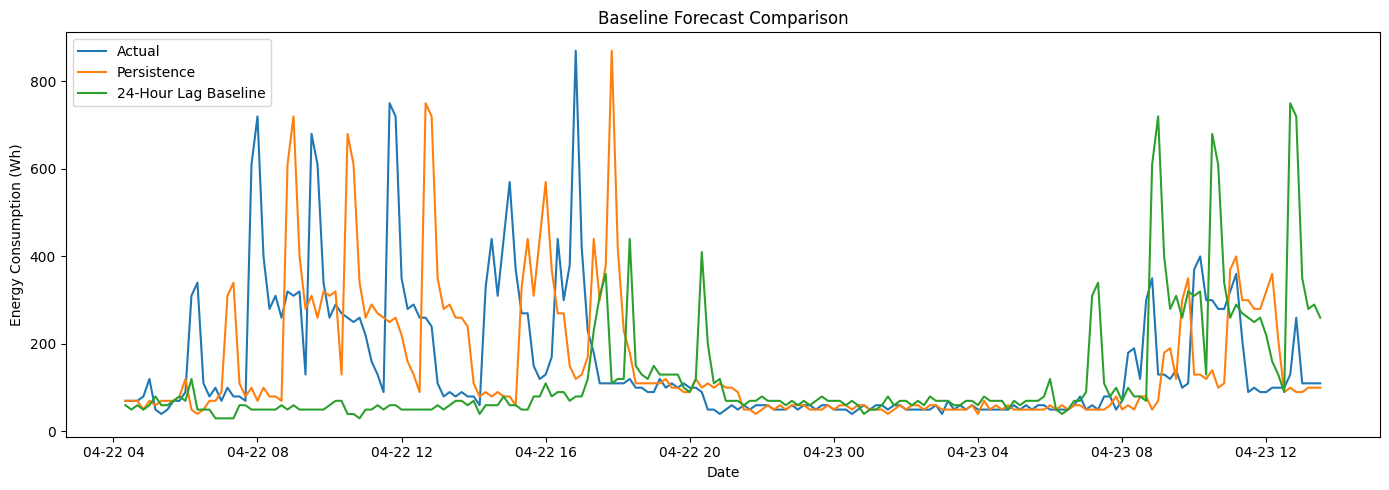

In [21]:
import matplotlib.pyplot as plt

plot_start = 500
plot_end = 700

plt.figure(figsize=(14, 5))

plt.plot(
    validation["date"].iloc[plot_start:plot_end],
    y_validation.iloc[plot_start:plot_end],
    label="Actual"
)

plt.plot(
    validation["date"].iloc[plot_start:plot_end],
    validation_pred_persistence.iloc[plot_start:plot_end],
    label="Persistence"
)

plt.plot(
    validation["date"].iloc[plot_start:plot_end],
    validation_pred_daily.iloc[plot_start:plot_end],
    label="24-Hour Lag Baseline"
)

plt.title("Baseline Forecast Comparison")
plt.xlabel("Date")
plt.ylabel("Energy Consumption (Wh)")
plt.legend()

plt.tight_layout()
plt.show()